In [20]:
# Wise / open exchange rates public
url = "https://cdn.jsdelivr.net/npm/@fawazahmed0/currency-api@latest/v1/currencies/usd.json"
r = requests.get(url, timeout=10)
print(r.status_code)
print(r.text[:200])

200
{
	"date": "2026-05-08",
	"usd": {
		"1inch": 10.35756292,
		"aave": 0.010773342,
		"ada": 3.81602767,
		"aed": 3.67250277,
		"afn": 64.50011511,
		"agix": 10.55903958,
		"akt": 1.59409977,
		"algo": 


In [21]:
url = "https://cdn.jsdelivr.net/npm/@fawazahmed0/currency-api@2005-01-01/v1/currencies/usd.json"
r = requests.get(url, timeout=10)
print(r.status_code)
print(r.text[:300])

404
Couldn't find the requested release version 2005-01-01.


In [18]:
url = "https://api.worldbank.org/v2/country/UA/indicator/NV.IND.TOTL.KD.ZG?format=json&per_page=30&date=2005:2025"
r = requests.get(url, timeout=20)
print(r.status_code)
print(r.text[:300])

200
[{"page":1,"pages":1,"per_page":30,"total":21,"sourceid":"2","lastupdated":"2026-04-08"},[{"indicator":{"id":"NV.IND.TOTL.KD.ZG","value":"Industry (including construction), value added (annual % growth)"},"country":{"id":"UA","value":"Ukraine"},"countryiso3code":"UKR","date":"2025","value":null,"uni


In [23]:
import requests
# Stooq - données historiques gratuites
url = "https://stooq.com/q/d/l/?s=uahusd&d1=20050101&d2=20251231&i=m"
r = requests.get(url, timeout=15)
print(r.status_code)
print(r.text[:300])

200
Get your apikey:

1. Open https://stooq.com/q/d/?s=uahusd&get_apikey
2. Enter the captcha code.
3. Copy the CSV download link at the bottom of the page - it will contain the <apikey> variable.
4. Append the <apikey> variable with its value to your requests, e.g.
   https://stooq.com/q/d/l/?s=uahusd&


# External Data — Programmatic Download

All data fetched via direct HTTP requests (FRED CSV API + NBU JSON API).
No external packages beyond `requests` and `pandas`.

| Variable | Source | Series ID |
|---|---|---|
| UAH/USD exchange rate | FRED | DEXUAEU |
| Brent crude oil (USD/bbl) | FRED | DCOILBRENTEU |
| ECB deposit rate | FRED | ECBDFR |
| EA industrial production YoY | FRED | EA19PRINTO01GYSAM |
| NBU policy rate | NBU API | — |
| Ukraine industrial production | FRED | UAPRINTO01GYSAM |

In [2]:
from pathlib import Path
from io import StringIO
import warnings
warnings.filterwarnings("ignore")

import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

cwd            = Path.cwd()
DATA_EXTERNAL  = cwd.parent / "data" / "data_external"
DATA_EXTERNAL.mkdir(parents=True, exist_ok=True)
OUTPUTS        = cwd.parent.parent / "outputs"
OUTPUTS.mkdir(parents=True, exist_ok=True)

START = "2005-01-01"
END   = "2025-12-31"

print("Output folder:", DATA_EXTERNAL)
print("Sample:", START, "→", END)

Output folder: c:\Users\hlarbi\Desktop\QMF Final Project (Ukraine_contrefactuel)\ukraine_counterfactual\data\data_external
Sample: 2005-01-01 → 2025-12-31


## Helper functions

In [11]:
def fetch_fred(series_id, start=START, end=END):
    url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}"
    r = requests.get(url, timeout=20)
    r.raise_for_status()

    df = pd.read_csv(StringIO(r.text), parse_dates=["observation_date"])
    df = df.rename(columns={"observation_date": "date", series_id: "value"})
    df = df.set_index("date")
    df["value"] = pd.to_numeric(df["value"], errors="coerce")
    df = df.loc[start:end]
    s = df["value"].resample("MS").mean()
    return s
    # Resample to monthly mean
    s = df["value"].resample("MS").mean()
    return s


print("Helper functions defined.")

Helper functions defined.


## 1. FRED series

In [12]:
FRED_SERIES = {
    "DEXUAEU":           "uah_usd",   # UAH per USD
    "DCOILBRENTEU":      "brent",     # Brent crude
    "ECBDFR":            "ecb_rate",  # ECB rate
    "EA19PRINTO01GYSAM": "ea_ip",     # EA industrial production
    "UAPRINTO01IXOBSAM": "ukr_ip",    # Ukraine industrial production
}

data = {}

for series_id, name in FRED_SERIES.items():
    try:
        s = fetch_fred(series_id)
        data[name] = s
        n = s.dropna()
        print(f"✓ {name:12s} — {len(n):3d} obs | {n.index.min().date()} → {n.index.max().date()}")
    except Exception as e:
        print(f"✗ {name:12s} — FAILED: {e}")

✗ uah_usd      — FAILED: 404 Client Error: Not Found for url: https://fred.stlouisfed.org/graph/fredgraph.csv?id=DEXUAEU
✓ brent        — 252 obs | 2005-01-01 → 2025-12-01
✓ ecb_rate     — 252 obs | 2005-01-01 → 2025-12-01
✓ ea_ip        — 226 obs | 2005-01-01 → 2023-10-01
✗ ukr_ip       — FAILED: 404 Client Error: Not Found for url: https://fred.stlouisfed.org/graph/fredgraph.csv?id=UAPRINTO01IXOBSAM


## 2. NBU policy rate — National Bank of Ukraine JSON API

In [5]:
try:
    url  = "https://bank.gov.ua/NBU_statistic/interest_rates/diskont_rate.json"
    resp = requests.get(url, timeout=15)
    resp.raise_for_status()

    nbu_raw = pd.DataFrame(resp.json())
    nbu_raw["date"] = pd.to_datetime(nbu_raw["date_start"], dayfirst=True)
    nbu_raw = nbu_raw.sort_values("date").set_index("date")["value"]

    # Forward-fill daily rate to monthly
    monthly_idx = pd.date_range(START, END, freq="MS")
    nbu_rate = nbu_raw.reindex(
        nbu_raw.index.union(monthly_idx)
    ).ffill().reindex(monthly_idx)
    nbu_rate.name = "nbu_rate"

    data["nbu_rate"] = nbu_rate
    n = nbu_rate.dropna()
    print(f"✓ nbu_rate    — {len(n):3d} obs | {n.index.min().date()} → {n.index.max().date()}")

except Exception as e:
    print(f"✗ nbu_rate — NBU API failed: {e}")
    print("  Will use ECB rate as proxy for policy rate comparison.")

✗ nbu_rate — NBU API failed: 404 Client Error: Not Found for url: https://bank.gov.ua/ua/NBU_statistic/interest_rates/diskont_rate.json
  Will use ECB rate as proxy for policy rate comparison.


## 3. Assemble and save

In [6]:
monthly_idx = pd.date_range(START, END, freq="MS")
external    = pd.DataFrame(index=monthly_idx)
external.index.name = "date"

for name, series in data.items():
    external[name] = series.reindex(monthly_idx)

print("External dataset shape:", external.shape)
print()
print("Coverage:")
for col in external.columns:
    n = external[col].dropna()
    if len(n) > 0:
        print(f"  {col:12s} — {len(n):3d} obs | {n.index.min().date()} → {n.index.max().date()}")
    else:
        print(f"  {col:12s} — NO DATA")

external.to_csv(DATA_EXTERNAL / "external_data.csv")
print("\nSaved → data/data_external/external_data.csv")

External dataset shape: (252, 3)

Coverage:
  brent        — 252 obs | 2005-01-01 → 2025-12-01
  ecb_rate     — 252 obs | 2005-01-01 → 2025-12-01
  ea_ip        — 226 obs | 2005-01-01 → 2023-10-01

Saved → data/data_external/external_data.csv


In [24]:
from pathlib import Path
import pandas as pd

DATA_EXTERNAL = Path.cwd().parent / "data" / "data_external"

# Sauvegarde ce qu'on a déjà
for name, series in data.items():
    if series is not None and len(series.dropna()) > 0:
        series.to_csv(DATA_EXTERNAL / f"{name}.csv", header=True)
        print(f"Saved: {name}.csv")

Saved: brent.csv
Saved: ecb_rate.csv
Saved: ea_ip.csv


## 4. Visual inspection

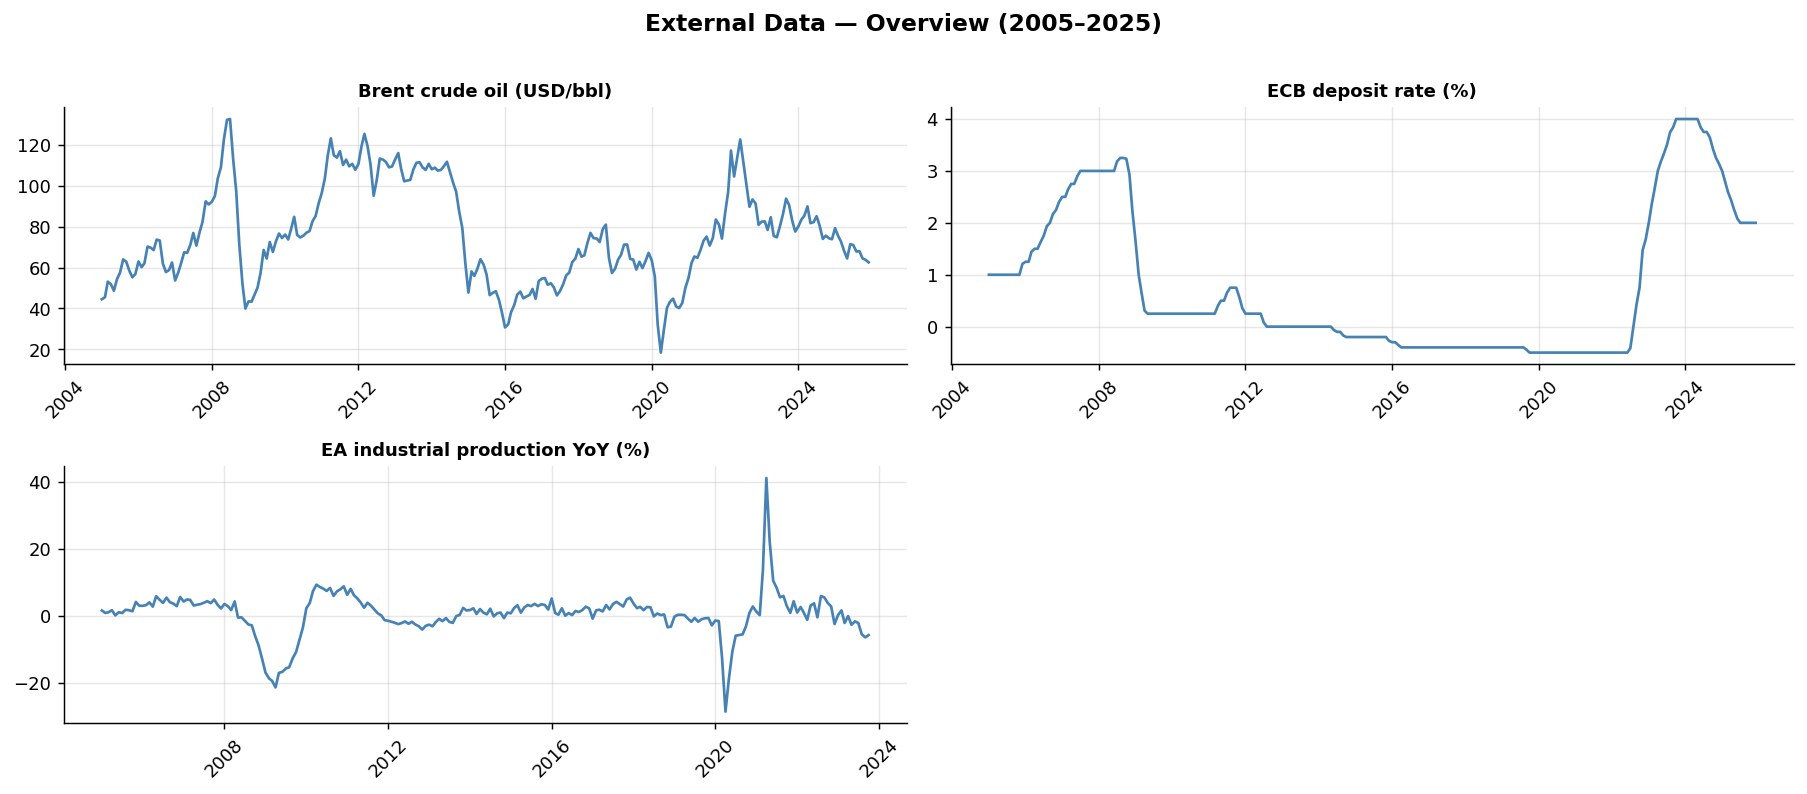

Figure saved.


In [7]:
TITLES = {
    "uah_usd":  "UAH / USD exchange rate",
    "brent":    "Brent crude oil (USD/bbl)",
    "ecb_rate": "ECB deposit rate (%)",
    "ea_ip":    "EA industrial production YoY (%)",
    "ukr_ip":   "Ukraine industrial production YoY (%)",
    "nbu_rate": "NBU policy rate (%)",
}

cols  = [c for c in external.columns if external[c].dropna().shape[0] > 10]
nrows = (len(cols) + 1) // 2

fig, axes = plt.subplots(nrows, 2, figsize=(14, nrows * 3))
axes = axes.flatten()

for i, col in enumerate(cols):
    axes[i].plot(external.index, external[col], lw=1.5, color="steelblue")
    axes[i].set_title(TITLES.get(col, col), fontsize=10, fontweight="bold")
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    axes[i].xaxis.set_major_locator(mdates.YearLocator(4))
    axes[i].tick_params(axis="x", rotation=45)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("External Data — Overview (2005–2025)", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(OUTPUTS / "fig4_external_data.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved.")

In [25]:
import pandas as pd
from pathlib import Path

DATA_EXTERNAL = Path.cwd().parent / "data" / "data_external"

# Charger UAH/USD
uah = pd.read_csv(DATA_EXTERNAL / "uahusd_m.csv", parse_dates=["Date"])
uah = uah.set_index("Date")[["Close"]]
uah.index = uah.index.to_period("M").to_timestamp()

# Inverser : on veut UAH par USD (ex: 27 UAH = 1 USD)
uah["uah_usd"] = 1 / uah["Close"]
uah = uah[["uah_usd"]]

print(uah.head())
print(f"\n{len(uah)} observations | {uah.index.min().date()} → {uah.index.max().date()}")

uah.to_csv(DATA_EXTERNAL / "uah_usd.csv")
print("Saved: uah_usd.csv")

             uah_usd
Date                
2005-01-01  5.305321
2005-02-01  5.296330
2005-03-01  5.278438
2005-04-01  5.011778
2005-05-01  5.084918

242 observations | 2005-01-01 → 2026-01-01
Saved: uah_usd.csv


In [28]:
url = "https://api.worldbank.org/v2/country/UA/indicator/NV.IND.TOTL.KD.ZG?format=json&per_page=30&date=2005:2025"
r = requests.get(url, timeout=20)
raw = r.json()
records = raw[1]
data_wb = pd.DataFrame([
    {"date": int(x["date"]), "value": x["value"]}
    for x in records if x["value"] is not None
]).sort_values("date")
print(data_wb)

    date      value
19  2005  -1.276451
18  2006   6.433295
17  2007   8.413043
16  2008  -6.150074
15  2009 -20.333080
14  2010   4.940698
13  2011   4.539730
12  2012  -2.751592
11  2013  -7.432668
10  2014 -14.464286
9   2015 -15.085414
8   2016   3.109913
7   2017   1.777210
6   2018   2.663865
5   2019   1.847312
4   2020  -3.202430
3   2021   2.180079
2   2022 -40.997200
1   2023   7.996753
0   2024   4.134181


In [29]:
from pathlib import Path
import pandas as pd
import numpy as np

DATA_EXTERNAL = Path.cwd().parent / "data" / "data_external"

# Interpolation annuel → mensuel
data_wb["date"] = pd.to_datetime(data_wb["date"].astype(str) + "-01-01")
data_wb = data_wb.set_index("date")["value"]

monthly_idx = pd.date_range("2005-01-01", "2025-12-01", freq="MS")
ukr_ip = data_wb.reindex(
    data_wb.index.union(monthly_idx)
).interpolate(method="time").reindex(monthly_idx)
ukr_ip.name = "ukr_ip"

print(ukr_ip.head(10))
print(f"\n{len(ukr_ip.dropna())} observations")

ukr_ip.to_csv(DATA_EXTERNAL / "ukr_ip.csv", header=True)
print("Saved: ukr_ip.csv")

2005-01-01   -1.276451
2005-02-01   -0.621651
2005-03-01   -0.030218
2005-04-01    0.624582
2005-05-01    1.258260
2005-06-01    1.913060
2005-07-01    2.546738
2005-08-01    3.201538
2005-09-01    3.856339
2005-10-01    4.490017
Freq: MS, Name: ukr_ip, dtype: float64

252 observations
Saved: ukr_ip.csv


In [30]:
from pathlib import Path
DATA_EXTERNAL = Path.cwd().parent / "data" / "data_external"
print([f.name for f in DATA_EXTERNAL.iterdir()])

['brent.csv', 'ea_ip.csv', 'ecb_rate.csv', 'external_data.csv', 'uahusd_m.csv', 'uah_usd.csv', 'ukr_ip.csv']
